<font size=10>**EXPLORATION**</font> <a class="anchor" id='title'></a> 


**Bachelor's in Data Science - NOVA IMS (25/26)**

**Project**: [*Seoul Bikes – Predicting Bike Rentals*](https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand)

**Group 8**
- Beatriz Marques 20231605
- David Carrilho 20231693
- Duarte Fernandes 20231619
- Filipe Caçador 20231707
- Mariana Calais-Pedro 20231641

*«notebook description»*

<font color='#BFD72' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a> 
- [1. Imports](#1)
- [2. Data](#2)
- [3. Dataset Exploration](#3)

# <font color='#BFD72F' size=6>**1. Imports**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

In [1]:
import warnings
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')

In [2]:
# Checking the installed Java version
!java -version
!pip install pyspark 

openjdk version "17.0.16" 2025-07-15
OpenJDK Runtime Environment (build 17.0.16+8-Ubuntu-0ubuntu124.04.1)
OpenJDK 64-Bit Server VM (build 17.0.16+8-Ubuntu-0ubuntu124.04.1, mixed mode, sharing)


In [3]:
# Install Java 17
!sudo apt-get update
!sudo apt-get install -y openjdk-17-jdk-headless

!java -version

Hit:1 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble InRelease
Hit:2 https://download.docker.com/linux/ubuntu noble InRelease                 
Hit:3 https://cli.github.com/packages stable InRelease                         
Hit:4 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-updates InRelease  
Hit:5 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:6 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-security InRelease 
Hit:7 https://archive.ubuntu.com/ubuntu noble InRelease                        
Hit:8 https://security.ubuntu.com/ubuntu noble-security InRelease              
Hit:9 https://archive.ubuntu.com/ubuntu noble-updates InRelease                
Hit:10 https://archive.ubuntu.com/ubuntu noble-backports InRelease             
Hit:11 https://us-east-2.ec2.archive.ubuntu.com/ubuntu noble InRelease
Get:12 https://us-east-2.ec2.archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Hit:13 https://packages.cloud.google.com/apt cloud-

In [4]:
# Set JAVA_HOME to Java 17
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

from pyspark.sql import SparkSession

spark = SparkSession.builder\
        .master("local[*]")\
        .appName("ML") \
        .getOrCreate()
        
print("Spark ready:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/07 12:23:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark ready: 4.0.1


In [5]:
import sys
import os

# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

# from spark_utils import *

In [73]:
# ===============================
# 📦 Import Required Libraries
# ===============================

# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# ===============================
# ⚙️ PySpark Modules
# ===============================

# Spark SQL
from pyspark.sql.functions import col, when, isnan, sum as spark_sum

# ===============================
# 🧩 Feature Engineering
# ===============================
from pyspark.ml.feature import (
    StringIndexer,   # Encodes categorical string values into numerical indices
    OneHotEncoder,   # Converts categorical variables into binary vectors
    VectorAssembler, # Combines multiple feature columns into a single vector
    Normalizer       # Normalizes feature vectors
)

# ===============================
# 📈 Statistical Analysis
# ===============================
from pyspark.ml.stat import Correlation  # Computes correlation matrices for features

# ===============================
# 🤖 Machine Learning Models
# ===============================
from pyspark.ml.classification import (
    LogisticRegression,  # Logistic Regression model
    RandomForestClassifier,  # Random Forest classifier
    GBTClassifier            # Gradient-Boosted Trees classifier
)

# ===============================
# 🧮 Model Evaluation & Tuning
# ===============================
from pyspark.ml.evaluation import BinaryClassificationEvaluator  # Evaluates classification models
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator   # Hyperparameter tuning tools

# ===============================
# 📊 Metrics
# ===============================
from sklearn.metrics import roc_curve, auc  # ROC curve and AUC calculation

# <font color='#BFD72F' size=6>**2. Data**</font> <a class="anchor" id="2"></a>
  
[Back to TOC](#toc)

In [6]:
data_path = "../../data/raw/SeoulBikeData.csv"

In [10]:
seoul_bikes_original = spark.read.load(data_path,
                     format      = "csv",           
                     sep         = ",",           
                     inferSchema = "true",        
                     header      = "true")

In [16]:
seoul_bikes_original

DataFrame[Date: string, Rented Bike Count: int, Hour: int, Temperature(�C): double, Humidity(%): int, Wind speed (m/s): double, Visibility (10m): int, Dew point temperature(�C): double, Solar Radiation (MJ/m2): double, Rainfall(mm): double, Snowfall (cm): double, Seasons: string, Holiday: string, Functioning Day: string]

**Target Column:** *Rented Bike Count*

In [51]:
# Making a copy to save the original file
seoul_bikes = seoul_bikes_original.alias('seoul_bikes')

In [54]:
seoul_bikes.show(5)

+----------+-----------------+----+-------------+-------------------+-------------+--------------+-----------------------+--------------------+----------+-----------+-------+----------+---------------+
|      Date|Rented_Bike_Count|Hour|Temperature_C|Humidity_Percentage|Wind_speed_ms|Visibility_10m|Dew_point_temperature_C|Solar_Radiation_MJm2|Rainfallmm|Snowfall_cm|Seasons|   Holiday|Functioning_Day|
+----------+-----------------+----+-------------+-------------------+-------------+--------------+-----------------------+--------------------+----------+-----------+-------+----------+---------------+
|01/12/2017|              254|   0|         -5.2|                 37|          2.2|          2000|                  -17.6|                 0.0|       0.0|        0.0| Winter|No Holiday|            Yes|
|01/12/2017|              204|   1|         -5.5|                 38|          0.8|          2000|                  -17.6|                 0.0|       0.0|        0.0| Winter|No Holiday|       

In [53]:
seoul_bikes = seoul_bikes.select(
    [col(c).alias(c.replace(" ", "_")
                  .replace("(", "")
                  .replace(")", "")
                  .replace("�", "_")
                  .replace("/", "")
                  .replace("%", "_Percentage")) for c in seoul_bikes.columns]
)

# <font color='#BFD72F' size=6>**3. Dataset Exploration**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

# <font color='#BFD72F' size=6>3.1 Initial Exploration</font> <a class="anchor" id="3_1"></a>

[Back to TOC](#toc)

In [55]:
seoul_bikes.printSchema()

root
 |-- Date: string (nullable = true)
 |-- Rented_Bike_Count: integer (nullable = true)
 |-- Hour: integer (nullable = true)
 |-- Temperature_C: double (nullable = true)
 |-- Humidity_Percentage: integer (nullable = true)
 |-- Wind_speed_ms: double (nullable = true)
 |-- Visibility_10m: integer (nullable = true)
 |-- Dew_point_temperature_C: double (nullable = true)
 |-- Solar_Radiation_MJm2: double (nullable = true)
 |-- Rainfallmm: double (nullable = true)
 |-- Snowfall_cm: double (nullable = true)
 |-- Seasons: string (nullable = true)
 |-- Holiday: string (nullable = true)
 |-- Functioning_Day: string (nullable = true)



In [56]:
seoul_bikes.show(5)

+----------+-----------------+----+-------------+-------------------+-------------+--------------+-----------------------+--------------------+----------+-----------+-------+----------+---------------+
|      Date|Rented_Bike_Count|Hour|Temperature_C|Humidity_Percentage|Wind_speed_ms|Visibility_10m|Dew_point_temperature_C|Solar_Radiation_MJm2|Rainfallmm|Snowfall_cm|Seasons|   Holiday|Functioning_Day|
+----------+-----------------+----+-------------+-------------------+-------------+--------------+-----------------------+--------------------+----------+-----------+-------+----------+---------------+
|01/12/2017|              254|   0|         -5.2|                 37|          2.2|          2000|                  -17.6|                 0.0|       0.0|        0.0| Winter|No Holiday|            Yes|
|01/12/2017|              204|   1|         -5.5|                 38|          0.8|          2000|                  -17.6|                 0.0|       0.0|        0.0| Winter|No Holiday|       

In [57]:
print(f"Rows: {seoul_bikes.count()}, Columns: {len(seoul_bikes.columns)}")

Rows: 8760, Columns: 14


In [58]:
seoul_bikes.describe().show()

+-------+----------+-----------------+-----------------+------------------+-------------------+------------------+-----------------+-----------------------+--------------------+------------------+-------------------+-------+----------+---------------+
|summary|      Date|Rented_Bike_Count|             Hour|     Temperature_C|Humidity_Percentage|     Wind_speed_ms|   Visibility_10m|Dew_point_temperature_C|Solar_Radiation_MJm2|        Rainfallmm|        Snowfall_cm|Seasons|   Holiday|Functioning_Day|
+-------+----------+-----------------+-----------------+------------------+-------------------+------------------+-----------------+-----------------------+--------------------+------------------+-------------------+-------+----------+---------------+
|  count|      8760|             8760|             8760|              8760|               8760|              8760|             8760|                   8760|                8760|              8760|               8760|   8760|      8760|         

In [75]:
from pyspark.sql.functions import col, when, isnan, sum as spark_sum
from pyspark.sql.types import StringType

# Total rows
total_rows = seoul_bikes.count()

# Identify string columns (only they can have "")
string_cols = [c for c, t in seoul_bikes.dtypes if t == 'string']

# Build missing counts safely
missing_counts = (
    seoul_bikes.select([
        spark_sum(
            when(
                col(c).isNull() | isnan(col(c)) | 
                ((col(c) == "") if c in string_cols else False),
                1
            ).otherwise(0)
        ).alias(c)
        for c in seoul_bikes.columns
    ])
    .toPandas()
    .T
    .reset_index()
    .rename(columns={"index": "Column", 0: "MissingCount"})
)

# Percentage
missing_counts["MissingPercentage"] = (missing_counts["MissingCount"] / total_rows) * 100

missing_counts

25/11/07 12:56:20 ERROR Executor: Exception in task 0.0 in stage 94.0 (TID 74)
org.apache.spark.SparkNumberFormatException: [CAST_INVALID_INPUT] The value '01/12/2017' of the type "STRING" cannot be cast to "DOUBLE" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018
== DataFrame ==
"isnan" was called from
java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)

	at org.apache.spark.sql.errors.QueryExecutionErrors$.invalidInputInCastToNumberError(QueryExecutionErrors.scala:145)
	at org.apache.spark.sql.errors.QueryExecutionErrors.invalidInputInCastToNumberError(QueryExecutionErrors.scala)
	at org.apache.spark.sql.catalyst.expressions.GeneratedClass$GeneratedIteratorForCodegenStage1.hashAgg_doAggregate_sum_0$(Unknown Source)
	at org.apache.spark.sql.catalyst.expressions.GeneratedClass$GeneratedIteratorForCodegenStage1.hashAgg_doConsume_0$(Unknow

NumberFormatException: [CAST_INVALID_INPUT] The value '01/12/2017' of the type "STRING" cannot be cast to "DOUBLE" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018
== DataFrame ==
"isnan" was called from
java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)


# <font color='#BFD72F' size=6>3.2 Categorical Distributions</font> <a class="anchor" id="3_2"></a>

[Back to TOC](#toc)

In [63]:
# Check distinct values per categorical column
for col_name in ["Seasons", "Holiday", "Functioning_Day"]:
    seoul_bikes.select(col_name).distinct().show()

+-------+
|Seasons|
+-------+
| Spring|
| Summer|
| Autumn|
| Winter|
+-------+

+----------+
|   Holiday|
+----------+
|No Holiday|
|   Holiday|
+----------+

+---------------+
|Functioning_Day|
+---------------+
|             No|
|            Yes|
+---------------+



In [64]:
import plotly.graph_objects as go

categorical_cols = ["Seasons", "Holiday", "Functioning_Day"]
pdf = seoul_bikes.select(categorical_cols).toPandas()

fig = go.Figure()

for col in categorical_cols:
    counts = pdf[col].value_counts().reset_index()
    fig.add_trace(go.Bar(
        x=counts['index'], 
        y=counts[col],
        name=col,
        visible=(col == categorical_cols[0])
    ))

fig.update_layout(
    updatemenus=[
        dict(
            buttons=[
                dict(label=col,
                     method="update",
                     args=[{"visible": [c == col for c in categorical_cols]},
                           {"title": f"Distribution of {col}"}])
                for col in categorical_cols
            ],
            direction="down",
            showactive=True
        )
    ],
    title=f"Distribution of {categorical_cols[0]}",
    xaxis_title="Category",
    yaxis_title="Count"
)

fig.show()

KeyError: 'index'

# <font color='#BFD72F' size=6>3.3 Numerical Summary</font> <a class="anchor" id="3_3"></a>

[Back to TOC](#toc)

# <font color='#BFD72F' size=6>3.4. Temporal Pattern — Rentals by Hour and by Season</font> <a class="anchor" id="3_4"></a>

[Back to TOC](#toc)

In [65]:
pdf_full = seoul_bikes.select("Hour", "Rented_Bike_Count", "Seasons").toPandas()

import plotly.express as px
fig = px.line(pdf_full.groupby(["Hour", "Seasons"], as_index=False)
              .mean(),
              x="Hour", y="Rented_Bike_Count", color="Seasons",
              title="Average Rented Bike Count by Hour and Season")
fig.show()


# <font color='#BFD72F' size=6>3.5. Relationship Between Weather and Rentals</font> <a class="anchor" id="3_5"></a>

[Back to TOC](#toc)

In [67]:
weather_cols = ["Temperature_C", "Humidity_Percentage", "Wind_speed_ms", "Visibility_10m", "Solar_Radiation_MJm2"]
pdf_weather = seoul_bikes.select(["Rented_Bike_Count"] + weather_cols).toPandas()

import plotly.express as px
for col in weather_cols:
    fig = px.scatter(pdf_weather, x=col, y="Rented_Bike_Count",
                     trendline="ols",
                     title=f"Rented Bike Count vs {col}")
    fig.show()

ModuleNotFoundError: No module named 'statsmodels'

6. Correlation Heatmap

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = pdf_weather.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


ModuleNotFoundError: No module named 'seaborn'

7. Rentals by Hour vs Holiday

In [ ]:
pdf_hour_holiday = seoul_bikes.select("Hour", "Rented_Bike_Count", "Holiday").toPandas()
fig = px.line(pdf_hour_holiday.groupby(["Hour", "Holiday"], as_index=False)
              .mean(),
              x="Hour", y="Rented_Bike_Count", color="Holiday",
              title="Average Bike Rentals by Hour and Holiday")
fig.show()


8. Seasonal Weather Impact

In [ ]:
pdf_weather_season = seoul_bikes.select("Seasons", *weather_cols).toPandas()
fig = px.box(pdf_weather_season.melt(id_vars="Seasons"),
             x="variable", y="value", color="Seasons",
             title="Weather Variable Distributions by Season")
fig.show()


9. Traget Distribution

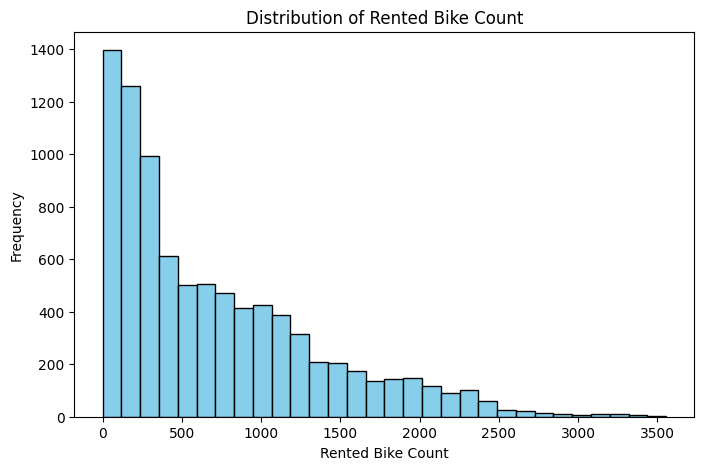

In [ ]:
# Target Distribution
pdf = seoul_bikes.select("Rented_Bike_Count").toPandas()

plt.figure(figsize=(8,5))
plt.hist(pdf["Rented_Bike_Count"], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Rented Bike Count")
plt.xlabel("Rented Bike Count")
plt.ylabel("Frequency")
plt.show()